In [219]:
import sys
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
import time
from wave_cluster import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

In [90]:
# US state level demographics and Covid-19 Time-Series data (# new cases every day)
demographics = pd.read_csv("../../data/demographics.csv", index_col = 0)
data = pd.read_csv("../data/state/infections.csv", index_col = 0)

# dropping the first 39 days for unreliable data 
data = data.iloc[39:,:]

# Dropping non-state and non-continental US locations.
dr = ['US_AK', 'US_HI', 'US_DC', 'US_PR', 'US_VI', 'US_MP', 'US_GU', 'US_AS']
data = data.drop(dr, axis = 1)

# Normalization of each locations time-series to be cases per 100,000 persons
population = demographics.loc[data.columns,"population"]
norm_data = data.apply(lambda x: x/population[x.name])
data = norm_data * 100000 # cases per 100,000

# Windowed average smoothing of each time-series 
# Using average of 7 days in front and behind burrent time-stamp, 
# and repeating 3 times for a smoother result. 
front = 7
back = 7
smooth_data = window_average_2d(data.to_numpy(), front = front, back = back)
smooth_data = window_average_2d(smooth_data, front = front, back = back)
smooth_data = window_average_2d(smooth_data, front = front, back = back)

# fix the index
smoothed_index = pd.to_datetime(data.index[front*3:-back*3])
data = pd.DataFrame(smooth_data, index = smoothed_index, columns = data.columns)

# remove any negative entries (reporting errors still present after smoothing)
data[data < 0] = 0
dataset = data.to_numpy()

In [40]:
data

,US_AL,US_AR,US_AZ,US_CA,US_CO,US_CT,US_DE,US_FL,US_GA,US_IA,...,US_SD,US_TN,US_TX,US_UT,US_VA,US_VT,US_WA,US_WI,US_WV,US_WY
2020-03-13,0.284479,0.330592,0.247569,0.285085,0.821039,1.005418,0.628630,0.336908,0.511470,0.216977,...,0.199866,0.488294,0.146198,0.438583,0.204405,0.738394,1.916854,0.463846,0.102300,0.329041
2020-03-14,0.344207,0.386151,0.302242,0.338113,0.971134,1.255746,0.755745,0.415319,0.617854,0.260228,...,0.236758,0.584898,0.181848,0.520726,0.248289,0.877909,2.106992,0.547561,0.129208,0.386826
2020-03-15,0.412333,0.446394,0.365056,0.398458,1.139437,1.547922,0.901776,0.507053,0.738437,0.309645,...,0.280267,0.692314,0.223712,0.613746,0.299661,1.034932,2.301825,0.639828,0.160924,0.451185
2020-03-16,0.489622,0.510375,0.436214,0.466237,1.325301,1.891346,1.068369,0.612323,0.874325,0.365340,...,0.331295,0.809545,0.272190,0.717054,0.358656,1.209785,2.499231,0.740108,0.197744,0.522633
2020-03-17,0.576454,0.578528,0.514805,0.542193,1.528075,2.288501,1.258727,0.731509,1.028258,0.427843,...,0.390209,0.936641,0.328214,0.829156,0.426498,1.400765,2.698032,0.848778,0.240577,0.601169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-22,43.691941,30.126201,20.153682,27.268389,16.812076,17.362460,24.417025,28.955584,29.511721,21.923056,...,23.100944,44.778837,27.817636,15.137193,28.572658,11.515469,17.242804,26.441054,45.637085,20.032595
2022-08-23,43.683320,30.163451,19.563845,26.756359,16.729028,17.263808,23.893451,28.415852,28.954673,21.762257,...,22.944686,44.833176,27.480469,14.812569,28.353255,11.490312,16.846385,26.067399,45.666769,19.415194
2022-08-24,43.658787,30.183040,18.996724,26.193932,16.660092,17.194146,23.397952,27.894991,28.380989,21.603956,...,22.799390,44.689290,27.170968,14.504247,28.131738,11.495703,16.482744,25.696151,45.725377,18.728451
2022-08-25,43.408470,30.183807,18.344670,25.650353,16.608743,17.153899,22.903919,27.365669,27.646704,21.443176,...,22.535530,44.392091,26.861004,14.234787,27.888083,11.457138,16.101092,25.310630,45.771894,18.128617


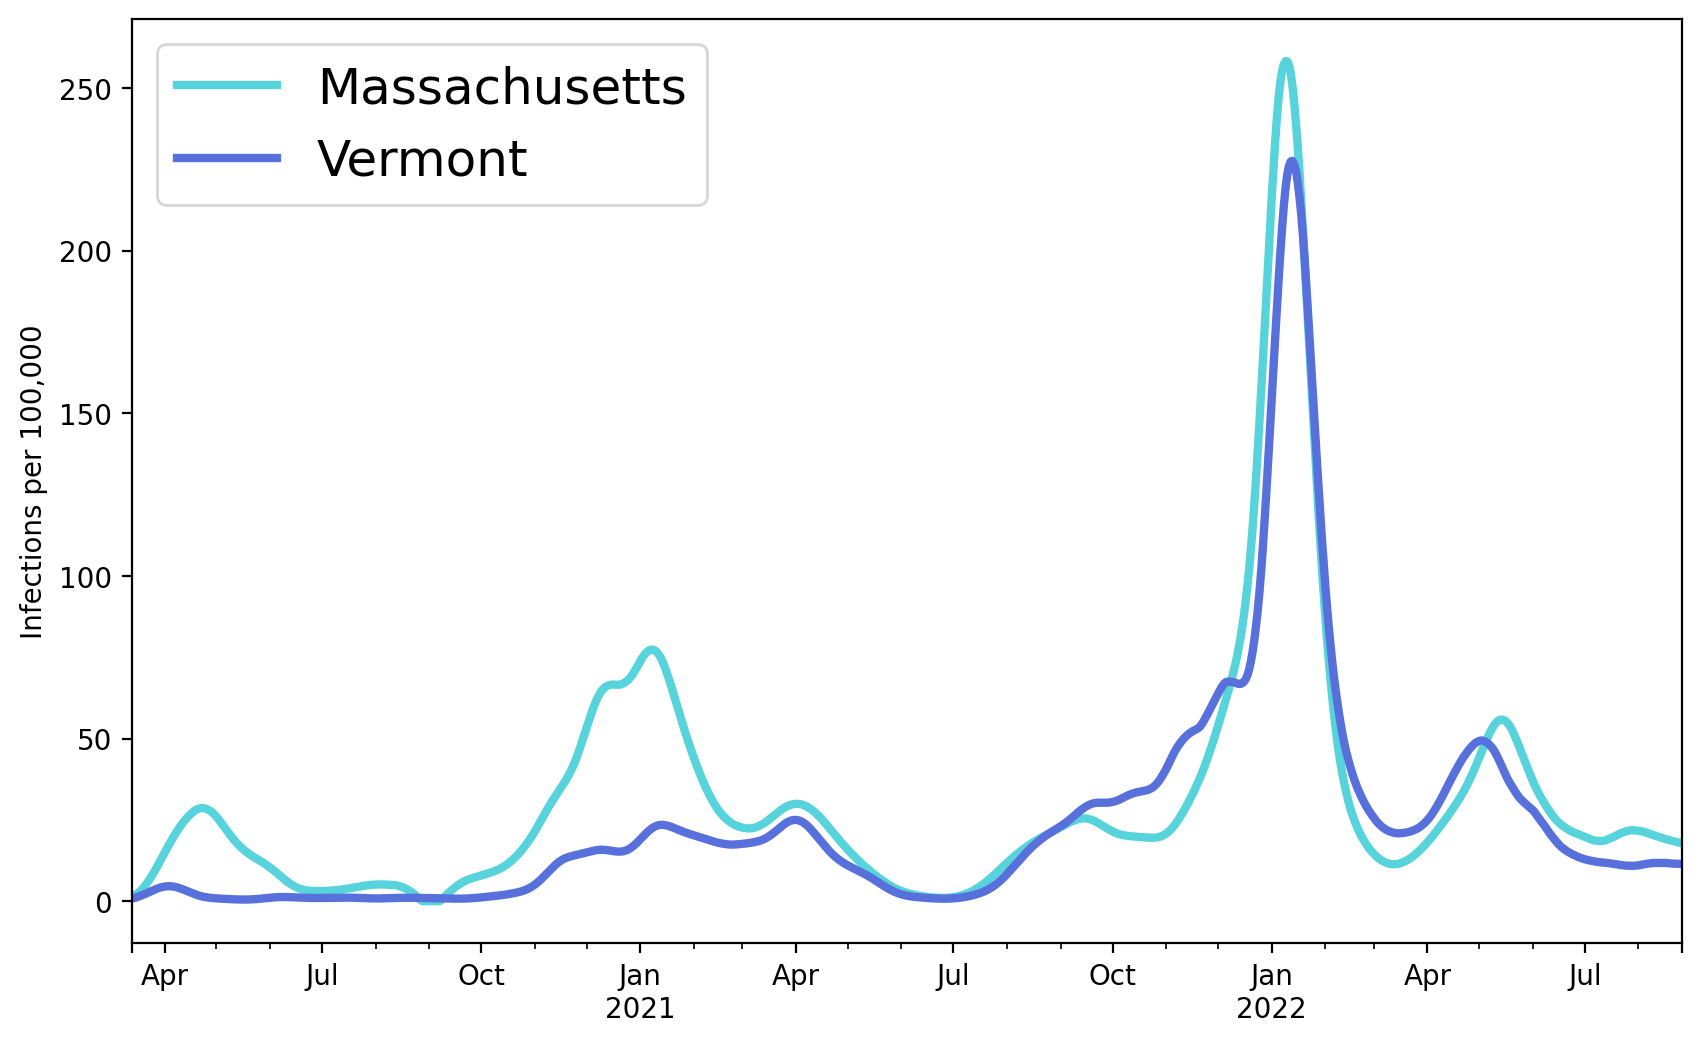

In [5]:
custom_palette = sns.color_palette("hls",8)[4:]
fix,ax = plt.subplots(dpi=200, figsize = (10,6))
plt.rcParams.update({'font.size':18})
sns.color_palette("hls", 8)
locations = ['US_MA', 'US_VT']
data.loc[:,locations].plot(ax=ax, color = custom_palette, linewidth = 3)
#sns.lineplot(data, x = data.index, y = locations[0], palette = 'hls')
#sns.lineplot(data, x = data.index, y = locations[1], palette = 'hls')
ax.set_ylabel('Infections per 100,000')
ax.set_xlabel('')
plt.legend(['Massachusetts', 'Vermont'])

### Map visualization

In [48]:
# json file with geographic info for each state -- required for graphing
state_map = gpd.read_file("../data/state/visualization/tl_rd22_us_state.shp")
sl = ['Hawaii', 'Alaska', 'Puerto Rico', 'United States Virgin Islands', 'Commonwealth of the Northern Mariana Islands', 'Guam', 'American Samoa'] 
state_map = state_map.drop(state_map.loc[state_map.NAME.isin(sl)].index, axis = 0)
state_map.index = range(len(state_map))

translator = {'US_AK': 'Alaska', 'US_AL':'Alabama', 'US_AR':'Arkansas', 'US_AZ':'Arizona', 'US_CA':'California',
             'US_CO':'Colorado', 'US_CT':'Connecticut', 'US_DC':'District of Columbia', 'US_DE':'Delaware', 
             'US_FL':'Florida', 'US_GA':'Georgia', 'US_HI':'Hawaii', 'US_IA': 'Iowa', 'US_ID':'Idaho',
             'US_IL':'Illinois', 'US_IN':'Indiana', 'US_KS':'Kansas', 'US_KY':'Kentucky', 'US_LA':'Louisiana',
             'US_MA':'Massachusetts', 'US_MD':'Maryland', 'US_ME':'Maine', 'US_MI':'Michigan', 'US_MN':'Minnesota',
             'US_MO':'Missouri', 'US_MS':'Mississippi', 'US_MT':'Montana', 'US_NC':'North Carolina', 'US_ND':'North Dakota',
             'US_NE':'Nebraska', 'US_NH':'New Hampshire', 'US_NJ':'New Jersey', 'US_NM':'New Mexico', 'US_NV':'Nevada',
             'US_NY':'New York', 'US_OH':'Ohio', 'US_OK':'Oklahoma', 'US_OR':'Oregon', 'US_PA':'Pennsylvania', 
             'US_PR':'Puerto Rico', 'US_RI':'Rhode Island', 'US_SC':'South Carolina', 'US_SD':'South Dakota',
             'US_TN':'Tennessee', 'US_TX':'Texas', 'US_UT':'Utah', 'US_VA':'Virginia', 'US_VT':'Vermont', 'US_WA':'Washington',
             'US_WI':'Wisconsin', 'US_WV':'West Virginia', 'US_WY':'Wyoming'}

data_locations = [translator[_] for _ in data.columns]

(20.0, 52.0)

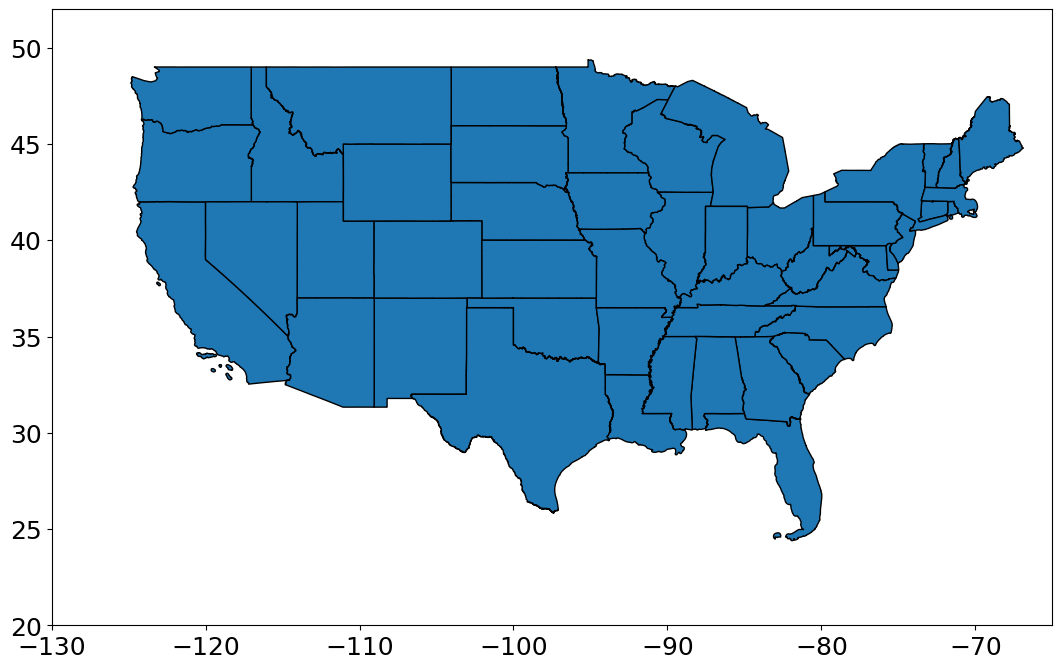

In [47]:
fig,ax = plt.subplots(figsize = (14,8))
state_map.plot(ax = ax, edgecolor="black")
ax.set_xlim(-130, -65)
ax.set_ylim(20,52)

# Segmentation

### Unimodal

In [220]:
# data vector to fit the model with
location = 'US_VT'
data_vec = data.loc[:,location].to_numpy().flatten().astype(np.float64)

In [ ]:
# Find an appropriate segmentation penalty
penalties = np.linspace(0,0.1,21)
error_array = np.zeros(len(penalties))
for i,p in enumerate(penalties):
    unifit = Unimodal(penalty = p)
    unifit.fit(data_vec)
    error_array[i] = np.sum(unifit.errors)

In [ ]:
np.linspace(0,0.1,21)

In [ ]:
plt.plot(penalties, error_array)

In [ ]:
unifit = Unimodal(penalty = 0.01, normalize = True)
unifit.fit(data_vec)
inflections = unifit.inflections
directions = unifit.directions
fit_vec = unifit.est
wave_inflections = unifit.waves

In [ ]:
# and visualize the results!
fig,ax = plt.subplots(dpi = 100)
ax.plot(data_vec, label = 'data')
ax.plot(fit_vec, label = 'k-modal fit')

for i in range(len(inflections)):
    if i == 0:
        ax.vlines(x = inflections[i], ymin = np.min(data_vec), ymax = np.max(data_vec), 
                  color = 'black', linestyle = '--', alpha = 0.7, label = 'segment boundaries')
    else:
        ax.vlines(x = inflections[i], ymin = np.min(data_vec), ymax = np.max(data_vec), 
                  color = 'black', linestyle = '--', alpha = 0.7)
plt.legend()
ax.set_ylabel('infections (per 100k)')
ax.set_xlabel('date')

In [ ]:
# Now showing the final result,
# which are the 'waves' instead of each isotonic piece.
fig,ax = plt.subplots(dpi = 100)
ax.plot(data_vec, label = 'data')
ax.plot(fit_vec, label = 'k-modal fit')

for i in range(len(wave_inflections)):
    if i == 0:
        ax.vlines(x = wave_inflections[i], ymin = np.min(data_vec), ymax = np.max(data_vec), 
                  color = 'black', linestyle = '--', alpha = 0.7, label = 'segment boundaries')
    else:
        ax.vlines(x = wave_inflections[i], ymin = np.min(data_vec), ymax = np.max(data_vec), 
                  color = 'black', linestyle = '--', alpha = 0.7)
plt.legend()
ax.set_ylabel('infections (per 100k)')
ax.set_xlabel('date')

# Dynamic Time Warp

Now that we have segments we'd like to be able to compare them. The problem is that these segments are varying in size and are usually offset in time. To avoid these issues we use dynamic time warping 

In [13]:
# first lets choose two segments to compare
#x = data.loc[:,'US_MA'][173:479].to_numpy()
#y = data.loc[:,'US_RI'][150:425].to_numpy()
x = data.loc[:,'US_MA'].to_numpy()
y = data.loc[:,'US_RI'].to_numpy()
x_masked = wave_mask(x, 173, 479)
y_masked = wave_mask(y, 173, 479)

# normalize them by the max of the larger 
norm = max(x_masked.max(), y_masked.max())

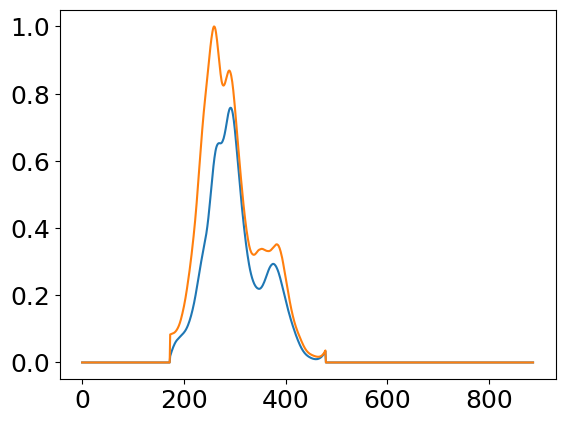

In [14]:
plt.plot(x_masked / norm)
plt.plot(y_masked / norm)

In [15]:
import time
DTW = DynamicTimeWarp(
    mult_penalty = [1.0,1.0,1.0],
    add_penalty = [0.05,0.05,0.0],
    normalize = True
)
start = time.time()
dist = DTW.fit(x_masked, y_masked)
end = time.time()
print(end - start)

3.686190128326416


In [16]:
dist

18.756994527035243

Text(0.5, 1.0, 'Alignment')

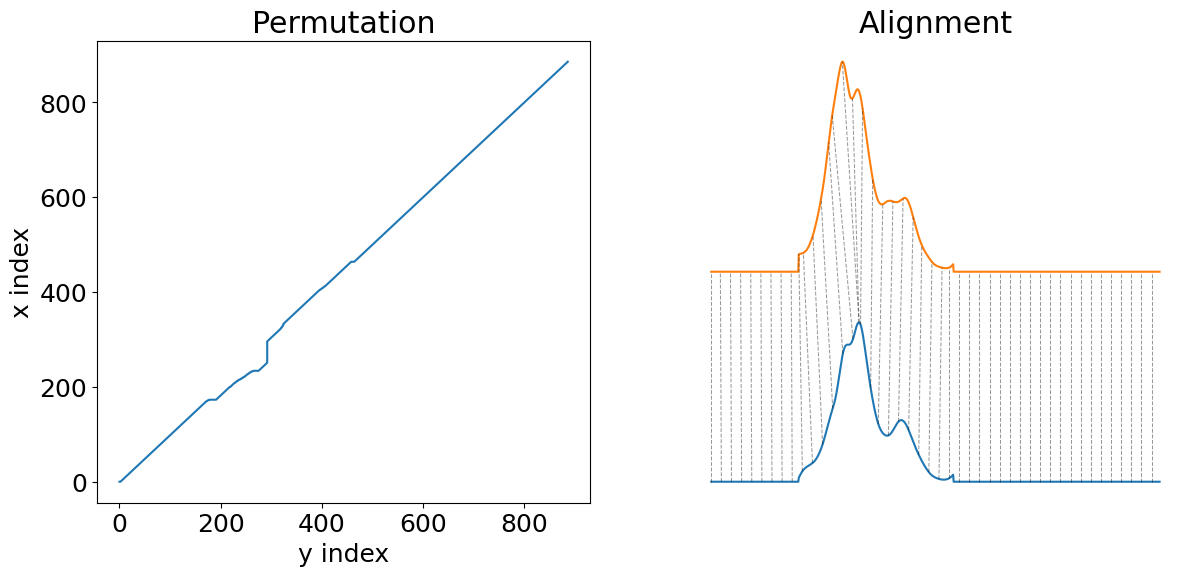

In [18]:
# and then plot the results
fig,ax = plt.subplots(1,2, figsize = (14,6), dpi = 100)
DTW.plot_permutation(axis = ax[0])
DTW.plot_alignment(x_masked / norm, y_masked / norm, offset = 1, skips = 20, axis = ax[1])
ax[0].set_ylabel('x index')
ax[0].set_xlabel('y index')
ax[1].axis('off')
ax[0].set_title('Permutation')
ax[1].set_title('Alignment')

### Wave Pool

In [5]:
wave_mod = Unimodal(penalty = 0.01, normalize = True)
dist_mod = DynamicTimeWarp(
    mult_penalty = [1.0,1.0,1.0],
    add_penalty = [0.05,0.05,0.0],
    normalize = True
)
wave_pool = WavePool(
    wave_module = wave_mod,
    distance_module = dist_mod,
    fit_waves_ = True,
    fit_distances_ = False,
    mask = True,
    cpu_count = 2
)

dataset = data.to_numpy()
#dataset = dataset[:,:5]

import time
start = time.time()
wave_pool.fit(dataset)
end = time.time()

In [30]:
pd.DataFrame(wave_pool.distances)

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,0.000000,69.374554,81.762047,55.101015,136.279547,59.872122,76.862208,53.544193,137.418884,16.485869,...,25.400136,60.455858,70.709683,50.655117,150.056914,46.333078,66.302447,82.569542,54.280250,154.885071
1,69.374554,0.000000,36.028172,64.013353,158.620233,28.612855,42.546109,60.987722,152.684832,52.614618,...,81.374039,19.957851,66.330360,64.051019,176.778273,32.485360,57.562170,69.409331,65.873667,179.228070
2,81.762047,36.028172,0.000000,34.438813,114.108935,50.765925,12.741019,33.945397,108.821878,69.924241,...,90.300891,37.268941,32.353136,34.802346,130.283510,55.133352,49.991678,31.843232,32.757900,104.592902
3,55.101015,64.013353,34.438813,0.000000,58.471679,75.847511,39.592068,6.049856,56.332936,55.308781,...,51.703145,55.711790,46.248338,4.263608,61.574196,74.045960,51.209513,41.154598,4.411367,53.642923
4,136.279547,158.620233,114.108935,58.471679,0.000000,169.112107,131.019938,56.424516,7.705200,137.025201,...,120.573753,110.290493,143.539142,53.461601,11.903479,140.286550,118.292063,165.072958,57.840850,25.258683
5,59.872122,28.612855,50.765925,75.847511,169.112107,0.000000,51.072557,71.359664,164.039036,45.256420,...,76.669144,28.942166,85.725300,74.044120,184.632044,25.184368,80.897843,74.856300,76.517321,188.922834
6,76.862208,42.546109,12.741019,39.592068,131.019938,51.072557,0.000000,38.052775,125.049541,65.999954,...,91.920488,42.030268,37.240209,39.154028,149.285041,48.469037,57.138051,32.440768,37.353052,119.435147
7,53.544193,60.987722,33.945397,6.049856,56.424516,71.359664,38.052775,0.000000,54.692234,53.721735,...,50.640623,55.353567,43.455489,3.474771,57.906886,70.869585,50.218801,37.710714,8.328303,49.829184
8,137.418884,152.684832,108.821878,56.332936,7.705200,164.039036,125.049541,54.692234,0.000000,127.669718,...,120.412480,105.845802,145.279653,51.773727,11.074890,134.842688,117.941841,156.738125,55.699436,21.931719
9,16.485869,52.614618,69.924241,55.308781,137.025201,45.256420,65.999954,53.721735,127.669718,0.000000,...,24.020846,50.113293,66.939226,50.828107,150.930576,39.686195,56.676104,73.216739,54.499724,155.745502


In [32]:
wave_pool.save_pool('../experiments/data/test_pool.npz')
wave_pool.save_distances('../experiments/data/test_distances.npz')

In [33]:
wave_pool.load_pool('../experiments/data/test_pool.npz')
wave_pool.load_distances('../experiments/data/test_distances.npz')

AttributeError: 'NpzFile' object has no attribute 'shape'

### Clustering

In [6]:
waves = WavePool()
waves.load_pool('../experiments/state/data/unimodal_pool.npz')
waves.load_distances('../experiments/state/data/unimodal_distances.npz')

In [7]:
D = waves.distances

In [183]:
clustering = AgglomerativeClustering(
    n_clusters = 20,
    metric = "precomputed",
    linkage = "complete"
).fit(D)

In [214]:
for t in range(0,len(data),2):
    timed_clusters = get_timed_clusters(pool, labels, t, percent = 1)
    print(f"{t} : " + str(timed_clusters))

0 : [ 0  7 15 17]
2 : [ 0  7 15 17]
4 : [ 0  7 15 17]
6 : [ 0  7 15 17]
8 : [ 0  7 15 17]
10 : [ 0  7 15 17]
12 : [ 0  7 15 17]
14 : [ 0  7 15 17]
16 : [ 0  7 15 17]
18 : [ 0  7 15 17]
20 : [ 0  7 15 17]
22 : [ 0  7 15 17]
24 : [ 0  7 15 17]
26 : [ 0  7 15 17]
28 : [ 0  7 15 17]
30 : [ 0  7 15 17]
32 : [ 0  7 15 17]
34 : [ 0  7 15 17]
36 : [ 0  7 15 17]
38 : [ 0  7 15 17]
40 : [ 0  7 15 17]
42 : [ 0  7 15 17]
44 : [ 0  7 15 17]
46 : [ 7  9 15 17]
48 : [ 7  9 15 17]
50 : [ 7  9 15 17]
52 : [ 7  9 15 17]
54 : [ 7  9 15 17]
56 : [ 7  9 15 17]
58 : [ 7  9 15 17]
60 : [ 7  9 15 17]
62 : [ 7  9 15 17]
64 : [ 7  9 15 17]
66 : [ 7  9 15 17]
68 : [ 7  9 15 17]
70 : [ 7  9 15 17]
72 : [ 7  9 15 17]
74 : [ 7  9 15 17]
76 : [ 7  9 15 17]
78 : [ 7  9 15 17]
80 : [ 7  9 15 17]
82 : [ 7  9 15 17]
84 : [ 7  9 15 17]
86 : [ 7  9 15 17]
88 : [ 7  9 15 17]
90 : [ 7  9 15 17]
92 : [ 7  9 15 17]
94 : [ 7  9 15 17]
96 : [ 7  9 13 15 17]
98 : [ 7  9 13 15 17]
100 : [ 7  9 13 15 17]
102 : [ 7  9 13 15 17]
104

In [215]:
pool = waves.pool
labels = clustering.labels_
time = 200
timed_clusters = get_timed_clusters(pool, labels, time, percent = 1.0)

([], [])

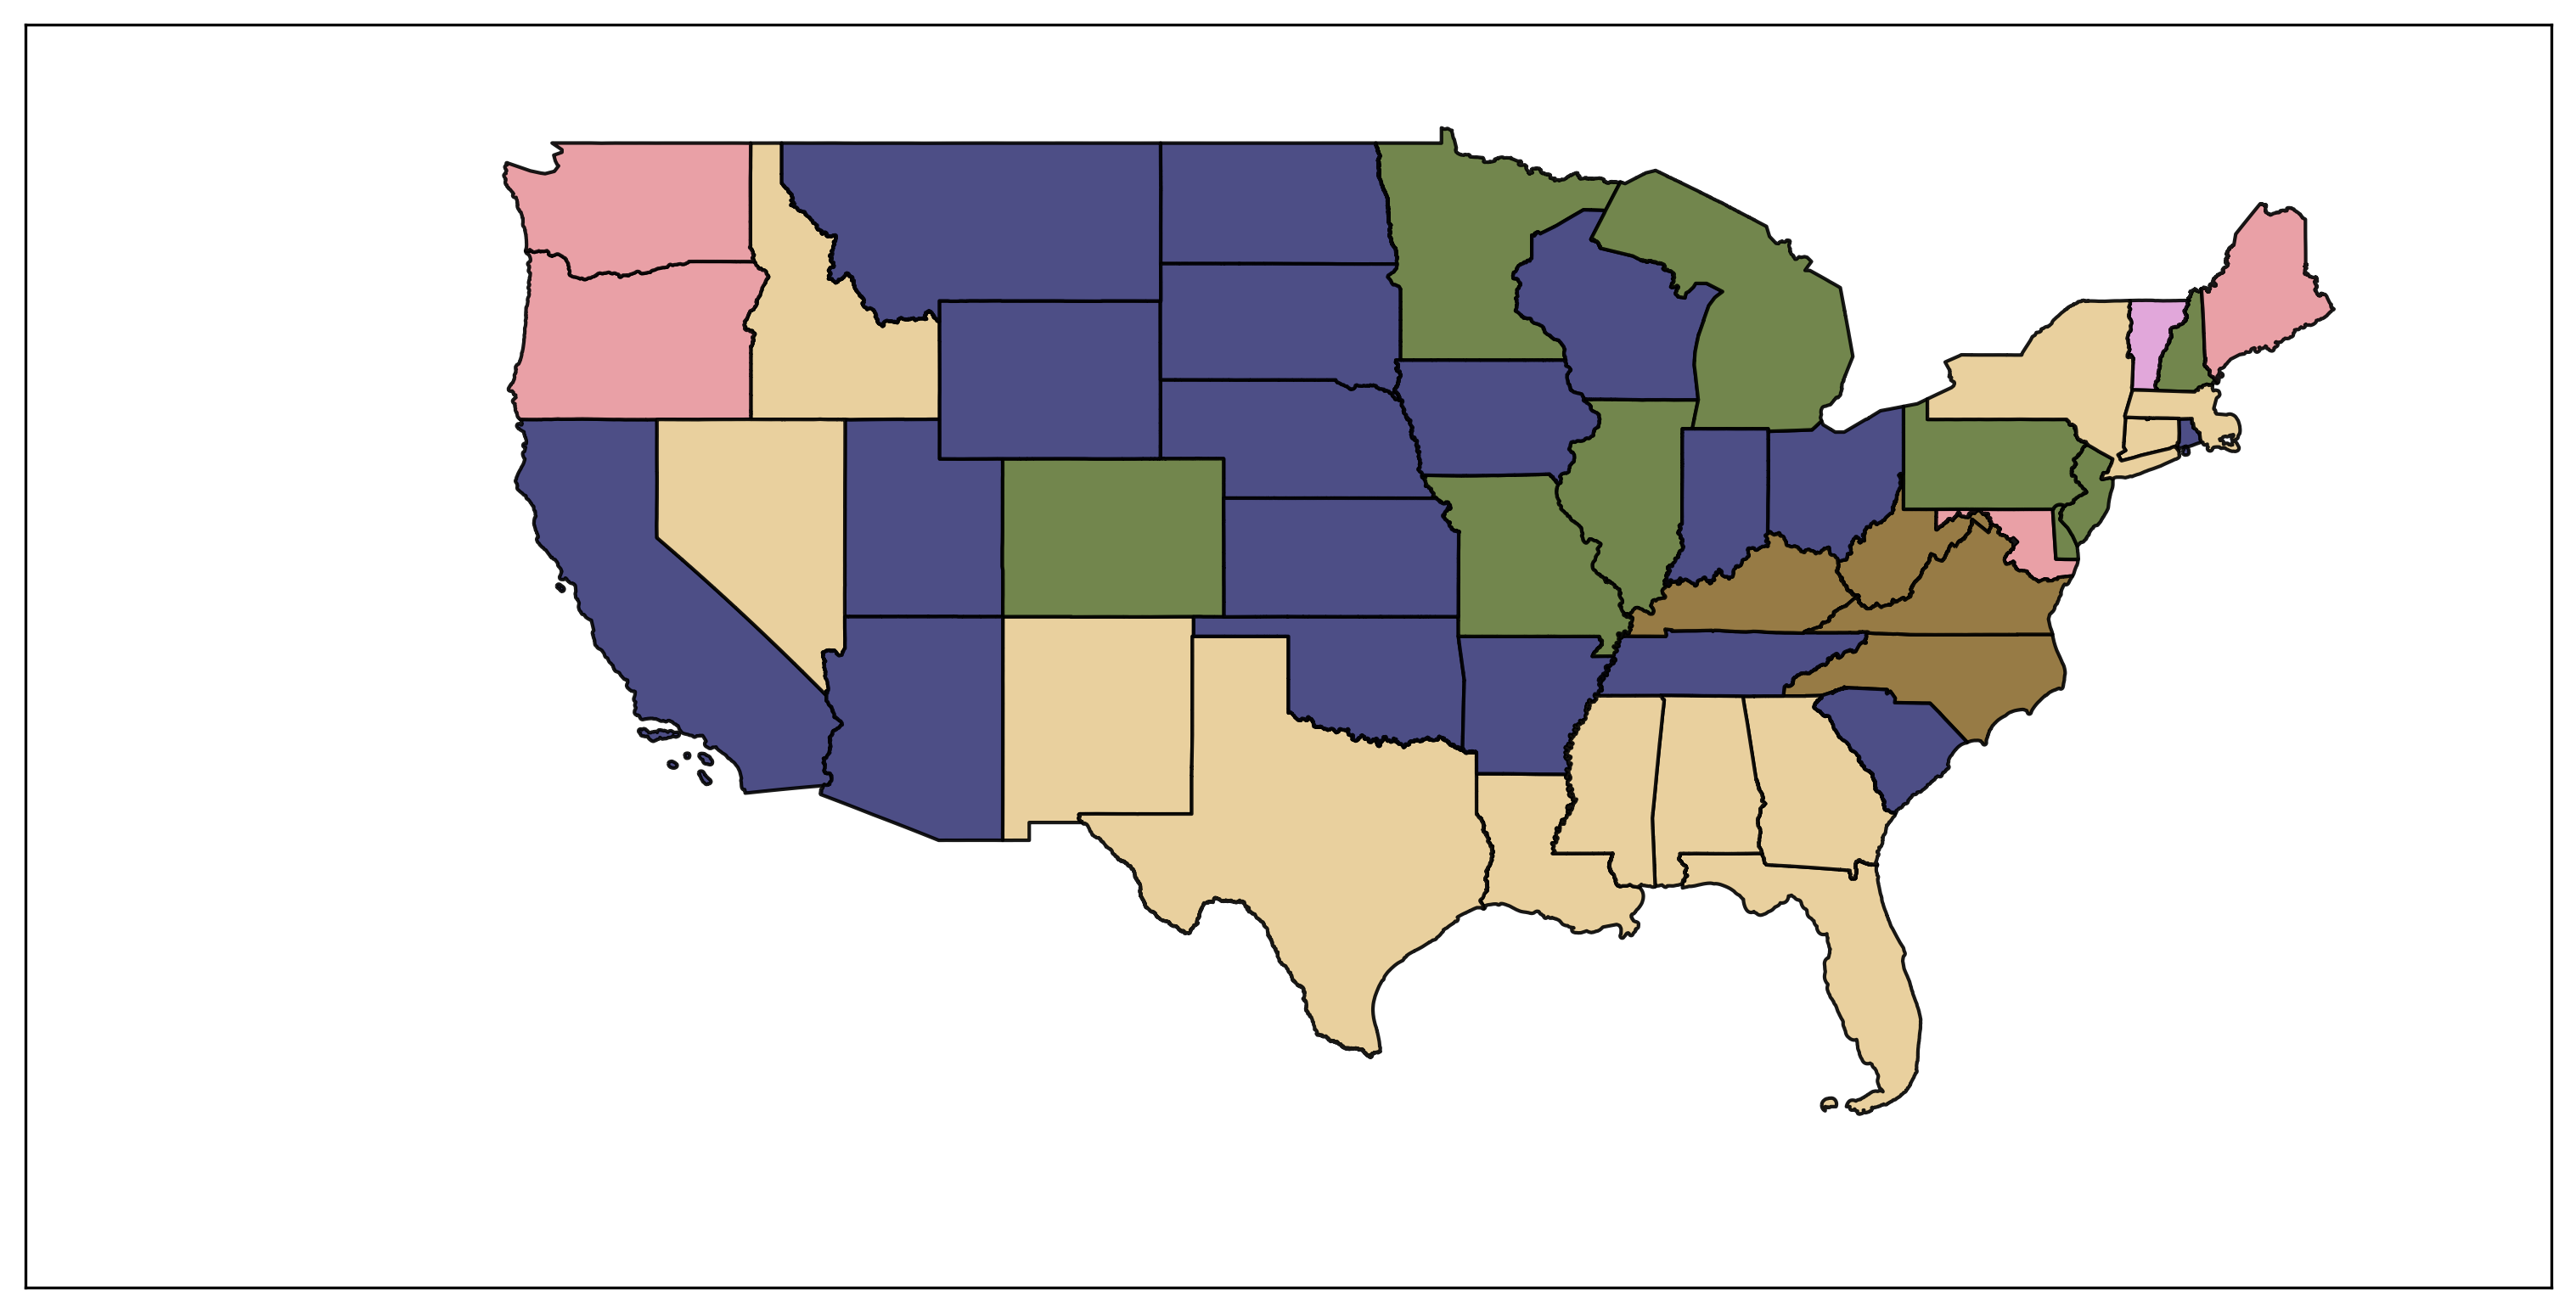

In [216]:
sequential_cmap = plt.cm.tab20b
colors = [(1, 1, 1)] + [sequential_cmap(i) for i in range(20)]
custom_cmap = ListedColormap(colors)

color_indices = np.round(
    np.linspace(1, len(colors) - 1, len(timed_clusters))
).astype(int)
color_dict = {
    timed_clusters[i]:colors[color_indices[i]] for i in range(len(timed_clusters))
}
color_dict[-1] = colors[0]

color_val = np.zeros(len(state_map)) - 1
for i in timed_clusters:
    clust = np.where(labels == i)[0]
    for j in clust:
        location = wave_locations[j]
        ind = state_map.loc[state_map.NAME == location].index[0]
        color_val[ind] = i
        
color_val = [color_dict[_] for _ in color_val]
state_map['color'] = color_val

fig,ax = plt.subplots(1,1, constrained_layout=True, figsize = (10,10), dpi = 300)
state_map.plot(color=state_map['color'], legend=False, ax = ax, edgecolor = 'black', alpha = 0.9)
ax.set_xlim(-140, -60)
ax.set_ylim(20,52)
plt.xticks([])
plt.yticks([]) 

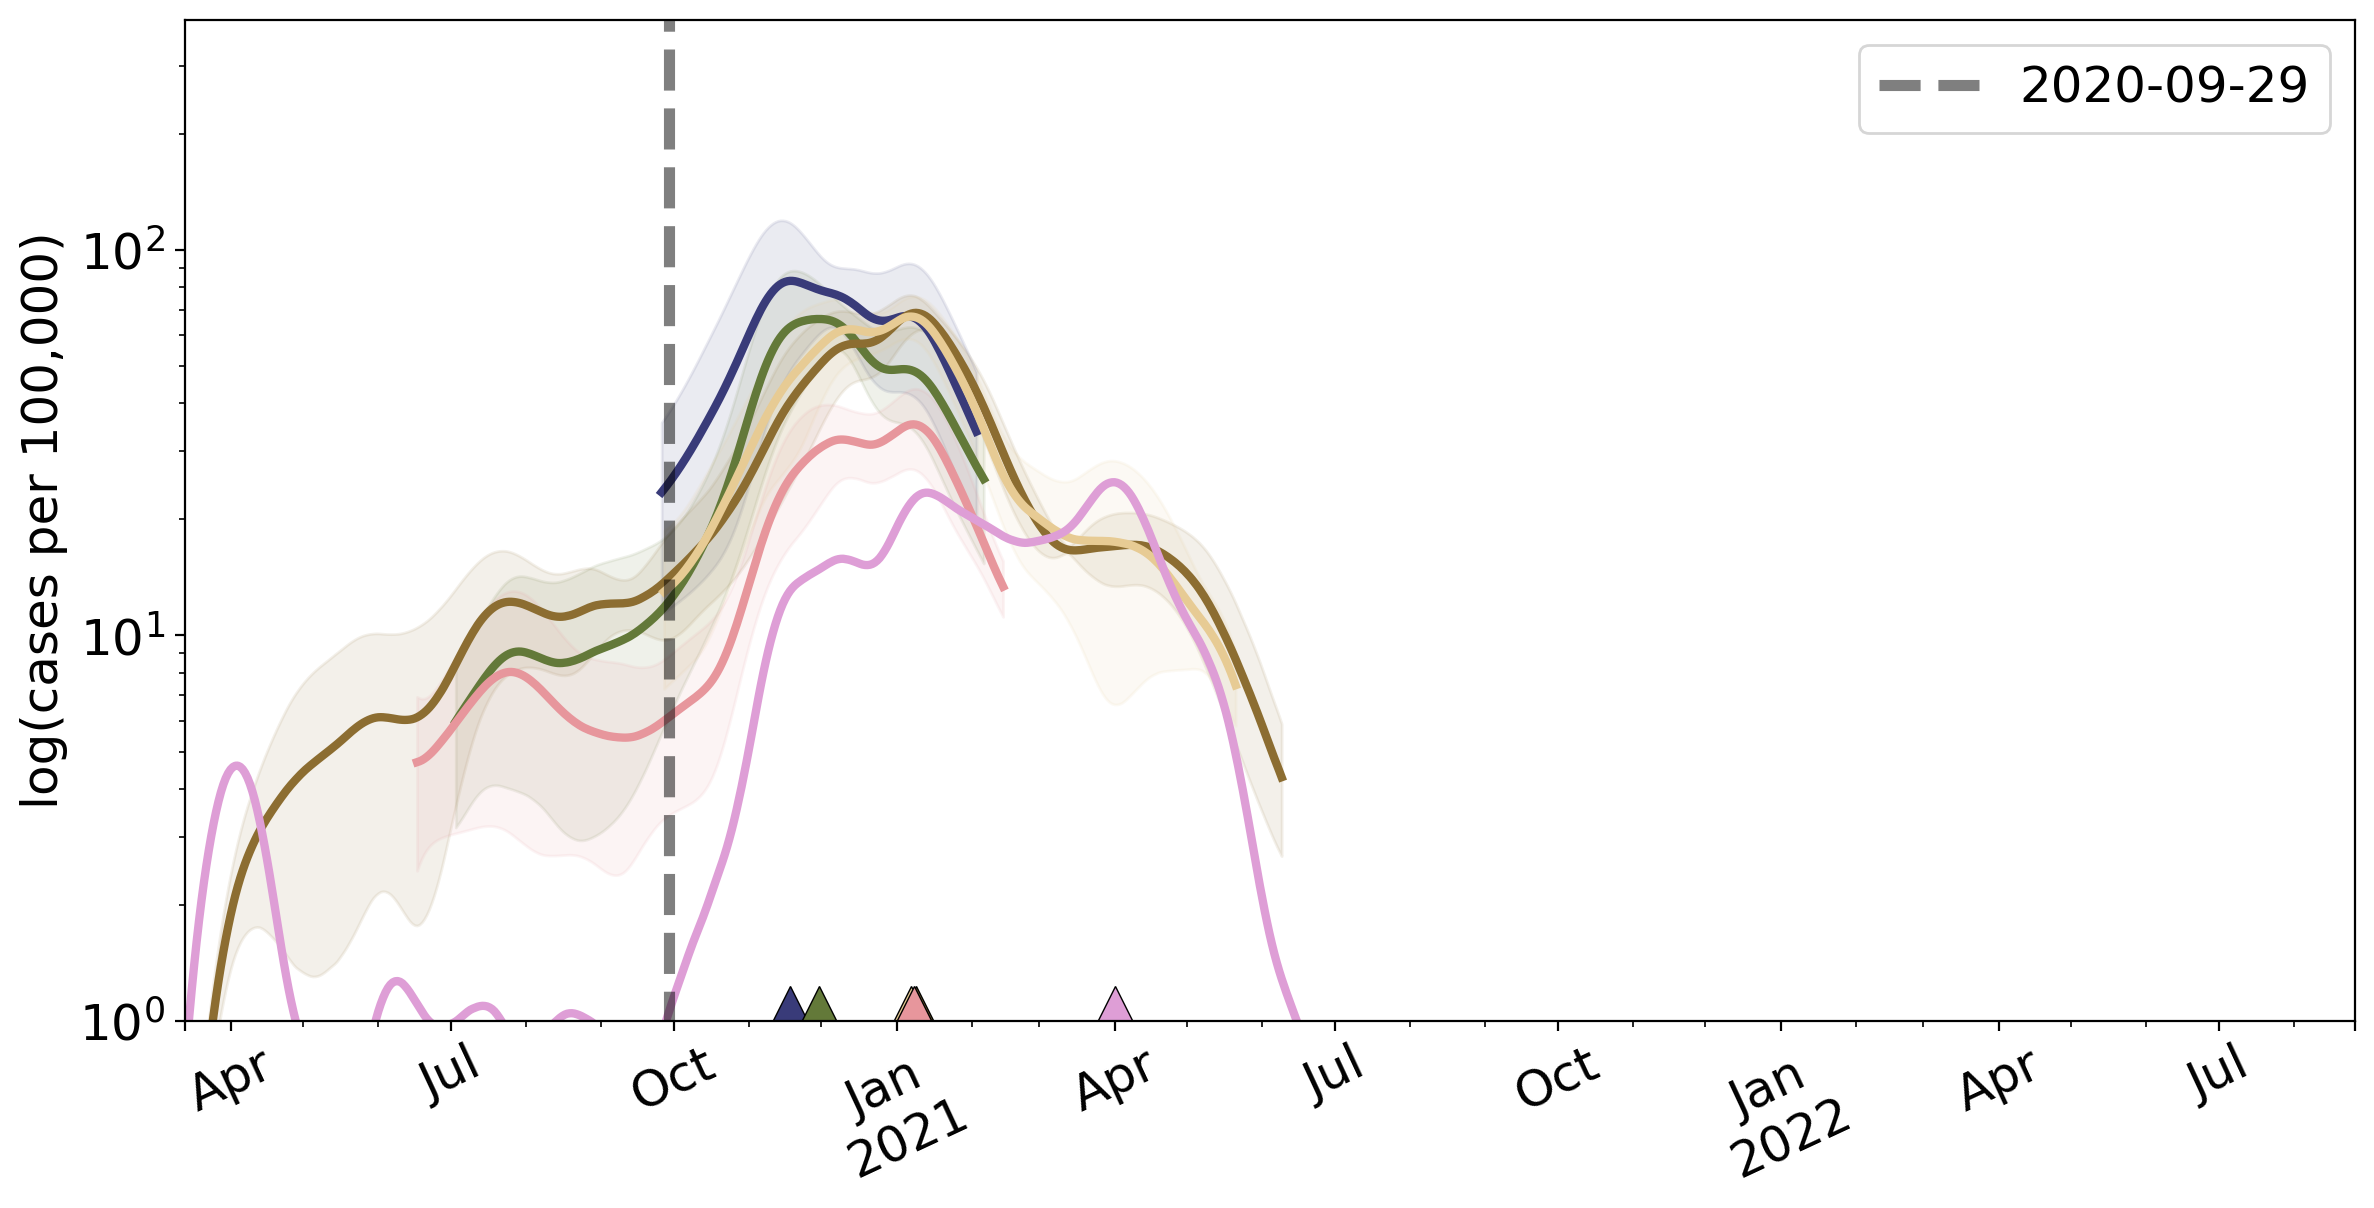

In [217]:
# For each of the clusters on the map,
# display the average wave associated with it
fig,ax = plt.subplots(figsize = (14,6.5), dpi = 200)
plt.rcParams.update({'font.size': 18})

for i in timed_clusters:
    clust_indices = np.where(clustering.labels_ == i)[0]
    clust_waves = get_common_segments(data, pool, clust_indices)

    if clust_waves is not None:
        idx = clust_waves.index
        mean = clust_waves.mean(axis = 1)
        std = clust_waves.std(axis = 1)
        max_idx = np.argmax(mean)
        clust_color = color_dict[i]
        
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore')
            mean.plot(c = clust_color, linewidth = 3, label='_no_legend_', ax = ax)
            ax.fill_between(idx, mean - std, mean + std, color=clust_color, alpha=0.1)
            ax.plot(idx[max_idx:max_idx + 1], 1, marker='^', markersize=25, c=clust_color, markeredgewidth=0.5, markeredgecolor='black')

    
data_max = data.max().max()
date_line = ax.vlines(x = data.index[time], ymin = 0, ymax = data_max, linestyle = '--', color = 'k', linewidth = 4, label = str(data.index[time])[:10], alpha = 0.5)
ax.set_xlabel('')
ax.set_ylabel('log(cases per 100,000)')
ax.set_yscale('log', base=10)
ax.set_ylim(1, data_max)
plt.xticks(rotation=25) 
plt.legend()